# Notebook 02 — Exploratory Data Analysis (EDA)
## Portfolio CW2 — Option 2: Real-World Data Analysis & Business Problem Solving

**Goal:** Explore the cleaned dataset to find patterns, trends, and insights that help understand late deliveries.

---

## 2.1 Import Libraries & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Create outputs folder
os.makedirs('../outputs', exist_ok=True)

print('✅ Libraries imported!')

✅ Libraries imported!


In [2]:
# Load cleaned data from notebook 01
df = pd.read_csv('../outputs/cleaned_data.csv')

print('✅ Cleaned data loaded!')
print(f'Shape: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

✅ Cleaned data loaded!
Shape: 10,999 rows, 11 columns


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Late_Delivery
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


---
## 2.2 Descriptive Statistics

In [3]:
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().round(2)

=== DESCRIPTIVE STATISTICS ===


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Late_Delivery
count,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00
mean,4.05,2.99,210.20,3.57,13.37,3634.02,0.60
std,1.14,1.41,48.06,1.52,16.21,1635.38,0.49
min,2.00,1.00,96.00,2.00,1.00,1001.00,0.00
25%,3.00,2.00,169.00,3.00,4.00,1839.50,0.00
50%,4.00,3.00,214.00,3.00,7.00,4149.00,1.00
75%,5.00,4.00,251.00,4.00,10.00,5050.00,1.00
max,7.00,5.00,310.00,10.00,65.00,7846.00,1.00


In [4]:
# Categorical columns summary
print('=== CATEGORICAL COLUMNS ===')
cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())

=== CATEGORICAL COLUMNS ===

Warehouse_block:
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

Mode_of_Shipment:
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

Product_importance:
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

Gender:
Gender
F    5545
M    5454
Name: count, dtype: int64


---
## 2.3 Missing Values & Outliers

In [5]:
# Missing values check
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')

=== MISSING VALUES ===
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Late_Delivery          0
dtype: int64

Total missing: 0


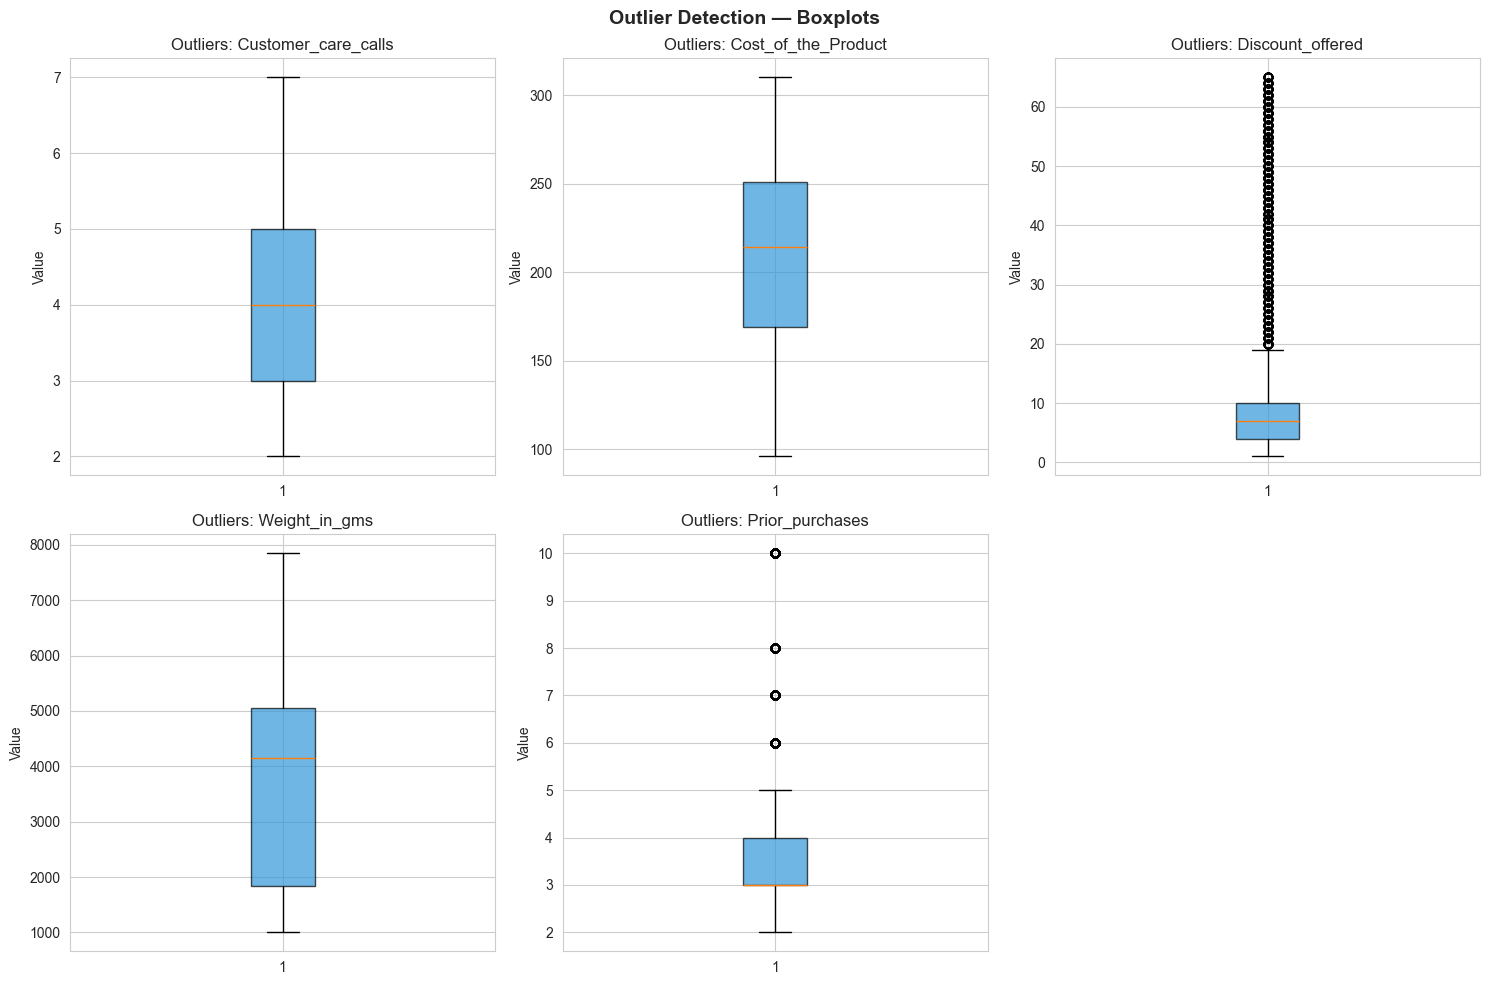

✅ Chart saved: outliers_boxplot.png


In [6]:
# Outlier detection using boxplots
numeric_cols = ['Customer_care_calls', 'Cost_of_the_Product', 
                'Discount_offered', 'Weight_in_gms', 'Prior_purchases']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[i].set_title(f'Outliers: {col}', fontsize=12)
    axes[i].set_ylabel('Value')

axes[5].axis('off')
plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/outliers_boxplot.png', dpi=150)
plt.show()
print('✅ Chart saved: outliers_boxplot.png')

---
## 2.4 Target Variable Distribution

=== DELIVERY STATUS ===
On Time  : 4,436 (40.3%)
Late     : 6,563 (59.7%)


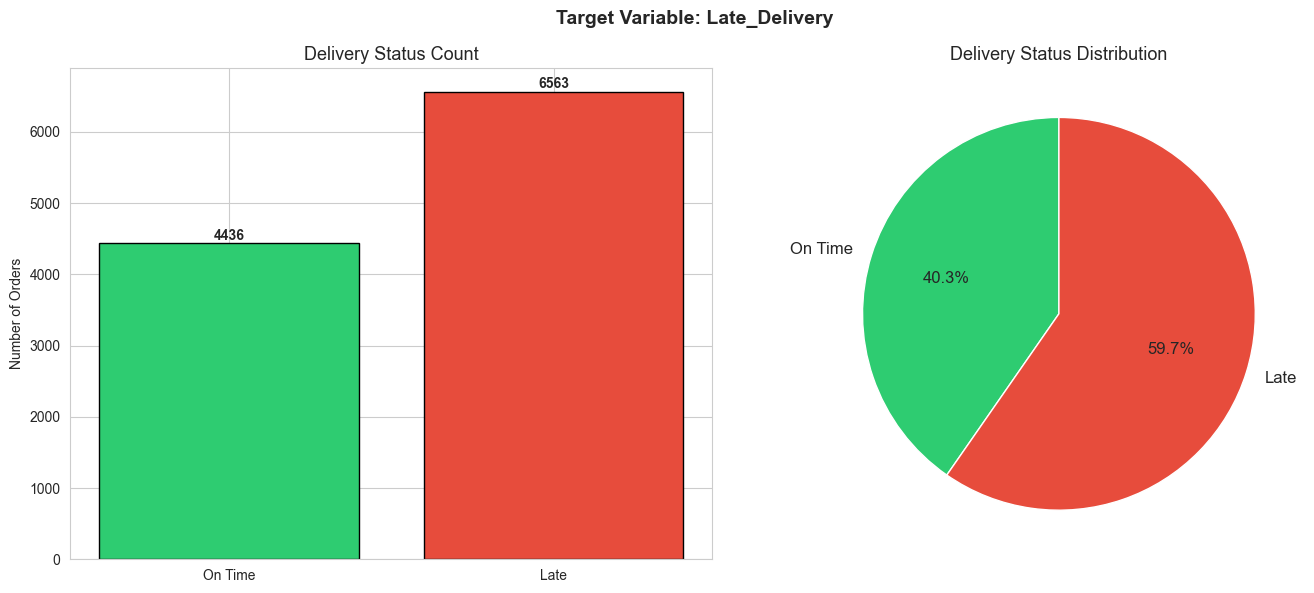

✅ Chart saved: target_distribution.png


In [7]:
# Delivery status distribution
late_count = df['Late_Delivery'].sum()
ontime_count = len(df) - late_count
late_pct = (late_count / len(df)) * 100
ontime_pct = 100 - late_pct

print('=== DELIVERY STATUS ===')
print(f'On Time  : {ontime_count:,} ({ontime_pct:.1f}%)')
print(f'Late     : {late_count:,} ({late_pct:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
ax1.bar(['On Time', 'Late'], [ontime_count, late_count], color=colors, edgecolor='black')
ax1.set_title('Delivery Status Count', fontsize=13)
ax1.set_ylabel('Number of Orders')
for i, v in enumerate([ontime_count, late_count]):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
ax2.pie([ontime_count, late_count], labels=['On Time', 'Late'],
        colors=colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('Delivery Status Distribution', fontsize=13)

plt.suptitle('Target Variable: Late_Delivery', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150)
plt.show()
print('✅ Chart saved: target_distribution.png')

---
## 2.5 Descriptive Visualizations

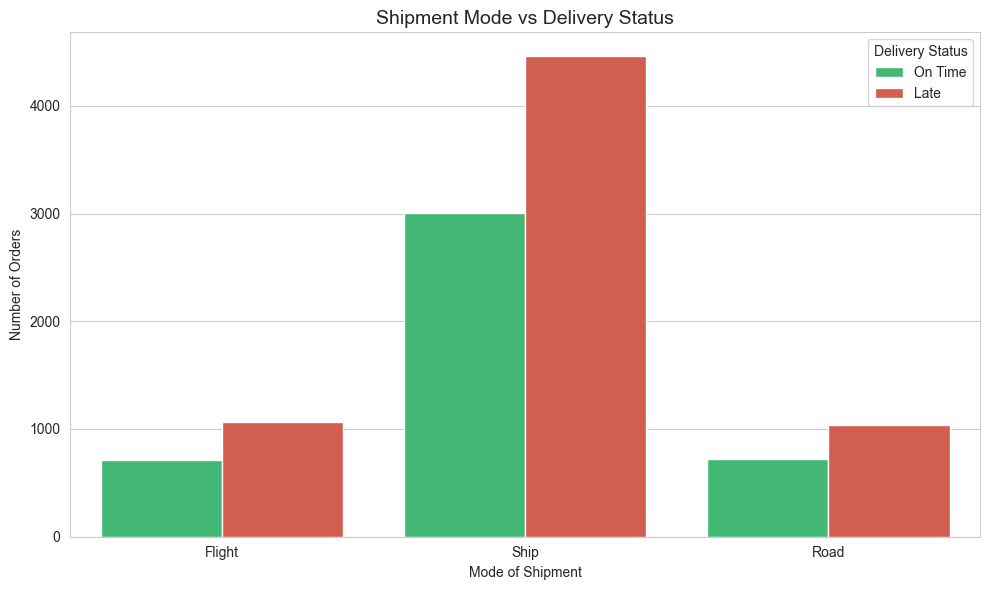

✅ Chart saved: shipment_mode.png


In [8]:
# Shipment Mode vs Late Delivery
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Mode_of_Shipment', hue='Late_Delivery',
              palette={0: '#2ecc71', 1: '#e74c3c'})
plt.title('Shipment Mode vs Delivery Status', fontsize=14)
plt.xlabel('Mode of Shipment')
plt.ylabel('Number of Orders')
plt.legend(['On Time', 'Late'], title='Delivery Status')
plt.tight_layout()
plt.savefig('../outputs/shipment_mode.png', dpi=150)
plt.show()
print('✅ Chart saved: shipment_mode.png')

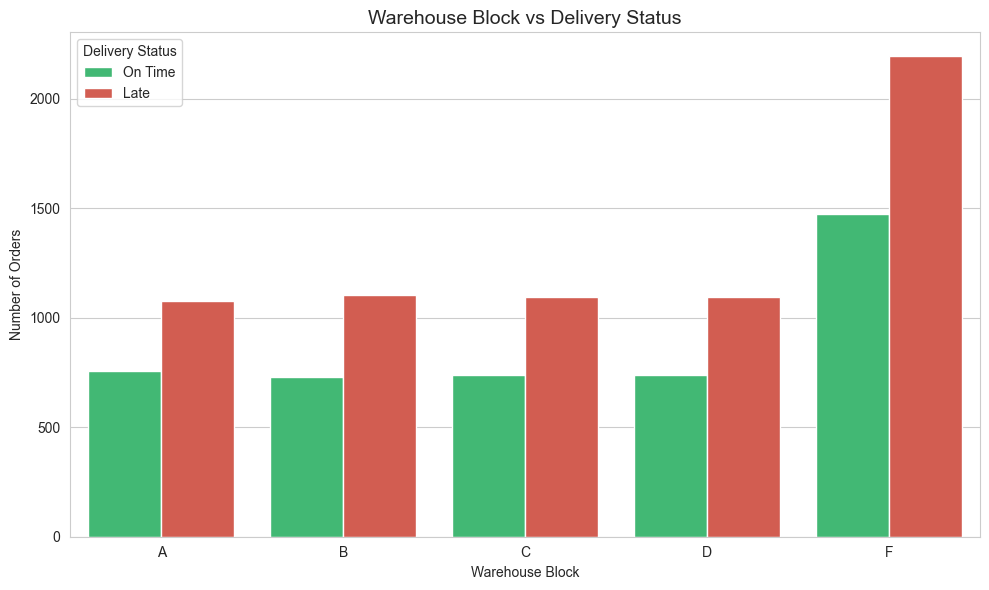

✅ Chart saved: warehouse_block.png


In [9]:
# Warehouse Block vs Late Delivery
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Warehouse_block', hue='Late_Delivery',
              palette={0: '#2ecc71', 1: '#e74c3c'},
              order=sorted(df['Warehouse_block'].unique()))
plt.title('Warehouse Block vs Delivery Status', fontsize=14)
plt.xlabel('Warehouse Block')
plt.ylabel('Number of Orders')
plt.legend(['On Time', 'Late'], title='Delivery Status')
plt.tight_layout()
plt.savefig('../outputs/warehouse_block.png', dpi=150)
plt.show()
print('✅ Chart saved: warehouse_block.png')

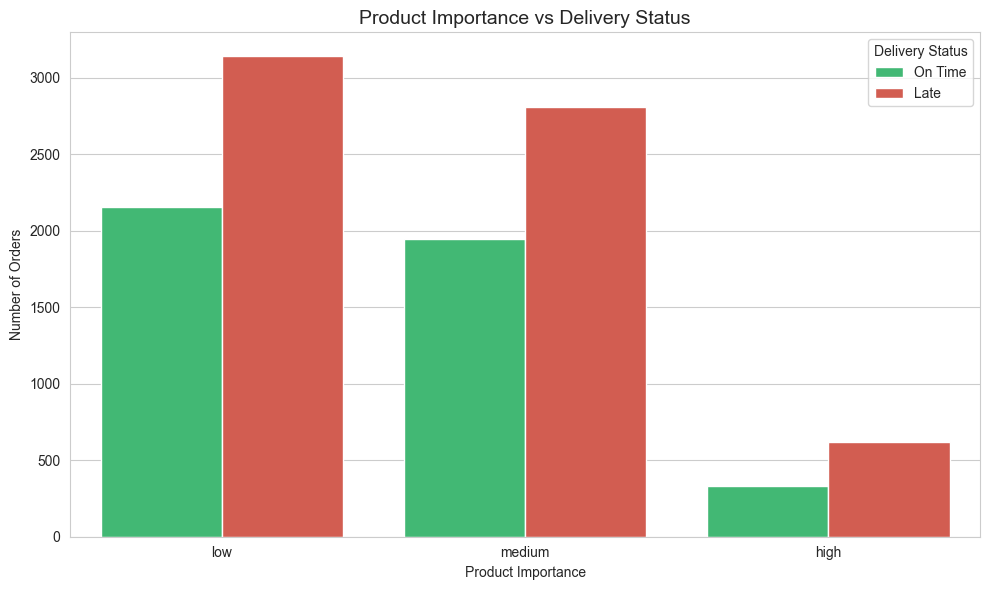

✅ Chart saved: product_importance.png


In [10]:
# Product Importance vs Late Delivery
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Product_importance', hue='Late_Delivery',
              palette={0: '#2ecc71', 1: '#e74c3c'},
              order=['low', 'medium', 'high'])
plt.title('Product Importance vs Delivery Status', fontsize=14)
plt.xlabel('Product Importance')
plt.ylabel('Number of Orders')
plt.legend(['On Time', 'Late'], title='Delivery Status')
plt.tight_layout()
plt.savefig('../outputs/product_importance.png', dpi=150)
plt.show()
print('✅ Chart saved: product_importance.png')

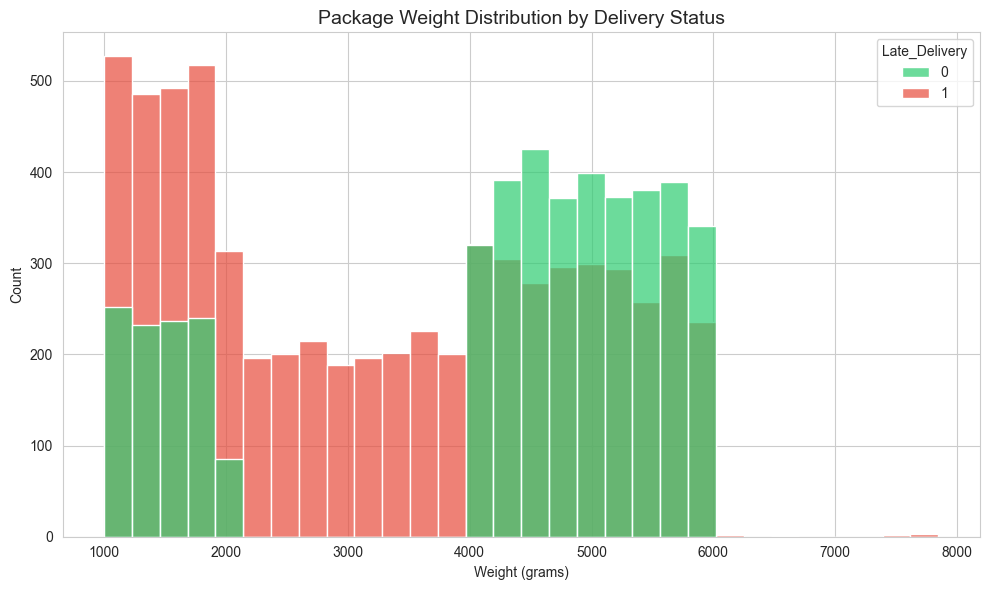

✅ Chart saved: weight_distribution.png


In [11]:
# Weight Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Weight_in_gms', hue='Late_Delivery',
             bins=30, palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.7)
plt.title('Package Weight Distribution by Delivery Status', fontsize=14)
plt.xlabel('Weight (grams)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/weight_distribution.png', dpi=150)
plt.show()
print('✅ Chart saved: weight_distribution.png')

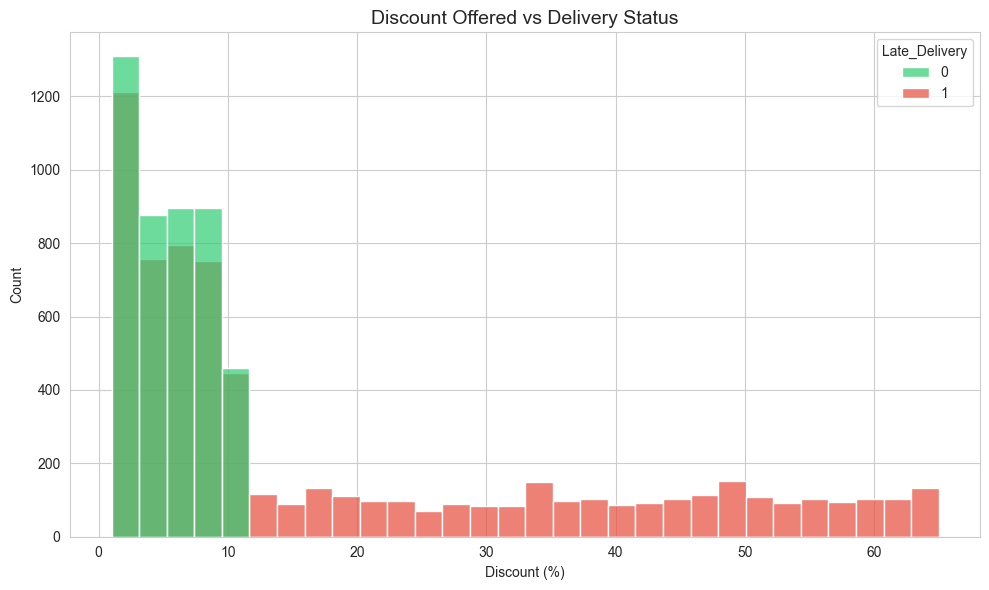

✅ Chart saved: discount_distribution.png


In [12]:
# Discount vs Late Delivery
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Discount_offered', hue='Late_Delivery',
             bins=30, palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.7)
plt.title('Discount Offered vs Delivery Status', fontsize=14)
plt.xlabel('Discount (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/discount_distribution.png', dpi=150)
plt.show()
print('✅ Chart saved: discount_distribution.png')

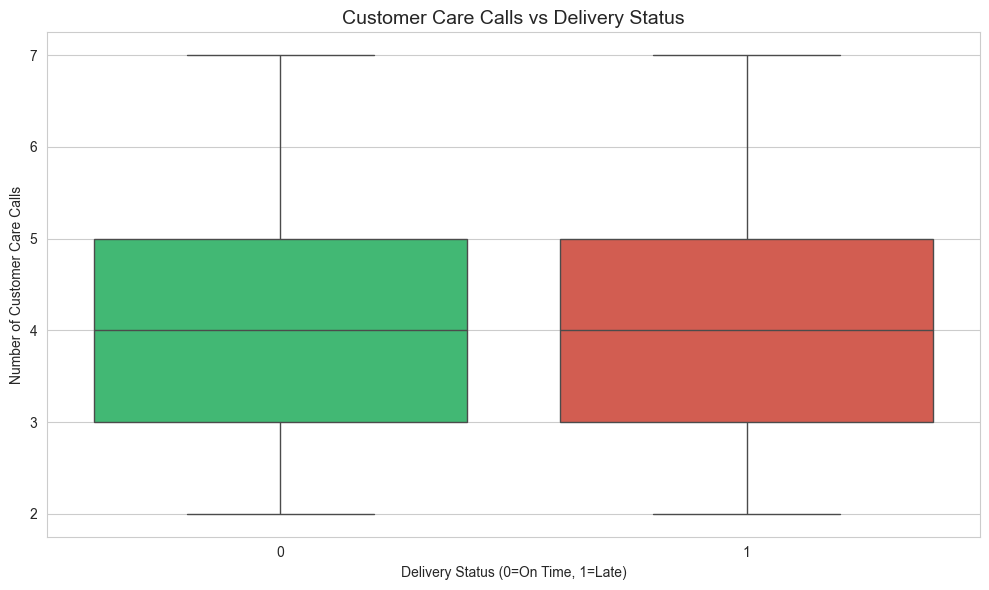

✅ Chart saved: customer_care_calls.png


In [14]:
# Customer Care Calls vs Late Delivery
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Late_Delivery', y='Customer_care_calls',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Care Calls vs Delivery Status', fontsize=14)
plt.xlabel('Delivery Status (0=On Time, 1=Late)')
plt.ylabel('Number of Customer Care Calls')
plt.tight_layout()
plt.savefig('../outputs/customer_care_calls.png', dpi=150)
plt.show()
print('✅ Chart saved: customer_care_calls.png')

---
## 2.6 Correlation Heatmap

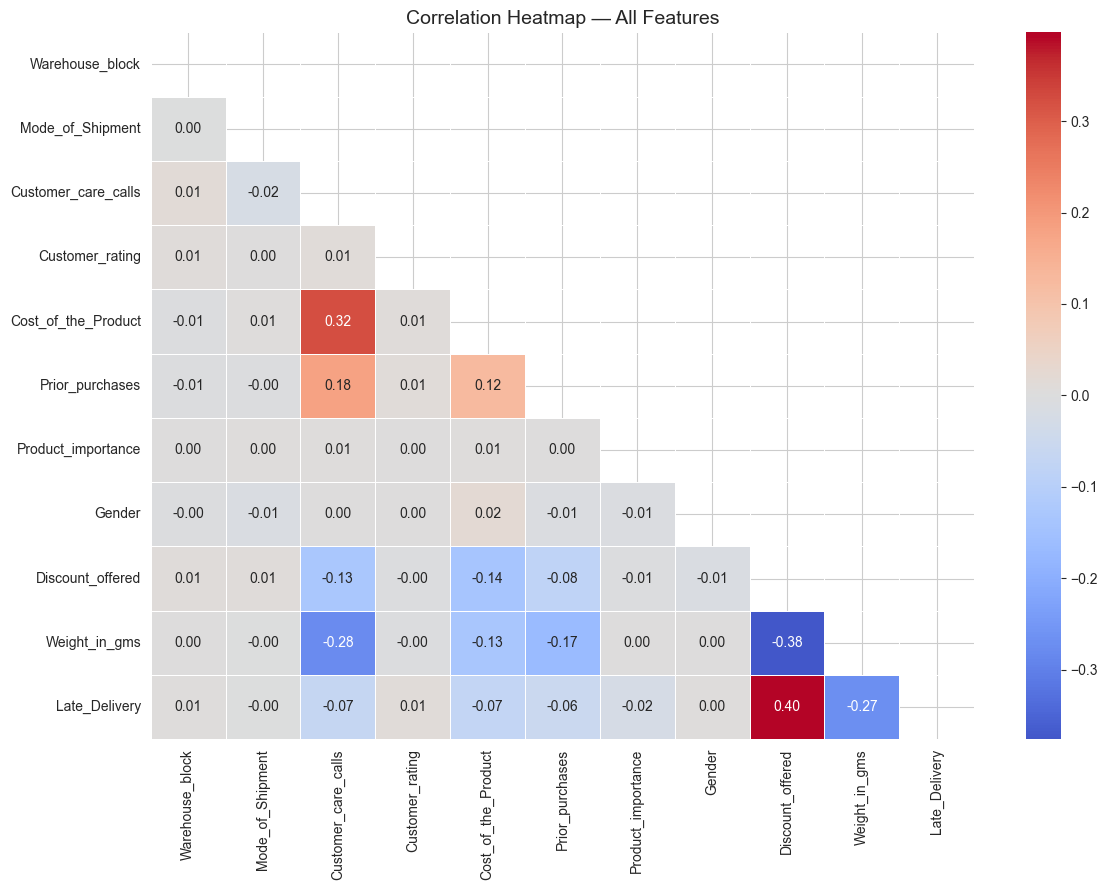

✅ Chart saved: correlation_heatmap.png


In [15]:
# Encode categorical columns for correlation
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
for col in ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap — All Features', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()
print('✅ Chart saved: correlation_heatmap.png')

---
## 2.7 Business Insights from EDA

In [16]:
print('=' * 55)
print('         KEY BUSINESS INSIGHTS FROM EDA')
print('=' * 55)
print()
print('1. DISCOUNT IMPACT')
print('   Orders with discount > 10% tend to arrive late')
print()
print('2. WEIGHT IMPACT')
print('   Heavier packages (>4000g) have more late deliveries')
print()
print('3. CUSTOMER CARE CALLS')
print('   Late deliveries generate more customer care calls')
print()
print('4. SHIPMENT MODE')
print('   Ship mode has highest volume but mixed performance')
print()
print('5. WAREHOUSE BLOCK')
print('   Some blocks show higher late delivery rates')
print()
print('✅ Notebook 02 Complete! Next: Run 03_clustering.ipynb')

         KEY BUSINESS INSIGHTS FROM EDA

1. DISCOUNT IMPACT
   Orders with discount > 10% tend to arrive late

2. WEIGHT IMPACT
   Heavier packages (>4000g) have more late deliveries

3. CUSTOMER CARE CALLS
   Late deliveries generate more customer care calls

4. SHIPMENT MODE
   Ship mode has highest volume but mixed performance

5. WAREHOUSE BLOCK
   Some blocks show higher late delivery rates

✅ Notebook 02 Complete! Next: Run 03_clustering.ipynb
